# DeepGuard v4 — Combined Training (FF++ + CelebDF)

Train on both FF++ and CelebDF combined for best detection accuracy.
Uses CLIP ViT-B/32 with last 4 layers unfrozen (same as v3).

- Cell 1: Setup
- Cell 2: Train on FF++ + CelebDF combined
- Cell 3: Evaluate on held-out validation sets
- Cell 4: Export model + results

In [1]:
# CELL 1: SETUP
# !pip install transformers seaborn -q

import os, time, json, io, random
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset, random_split
from torchvision import transforms
from PIL import Image, ImageFilter
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from transformers import CLIPModel
import warnings; warnings.filterwarnings('ignore')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

ROOT = "/teamspace/studios/this_studio"
FF_TRAIN   = os.path.join(ROOT, "ff_data/dataset_processed_split/train")
FF_VAL     = os.path.join(ROOT, "ff_data/dataset_processed_split/val")
CELEB_DATA = os.path.join(ROOT, "celebdf/frames")
SAVE_DIR   = os.path.join(ROOT, "models_v4")
os.makedirs(SAVE_DIR, exist_ok=True)
REAL, FAKE = 0, 1

for p, n in [(FF_TRAIN,"FF++ train"),(FF_VAL,"FF++ val"),(CELEB_DATA,"CelebDF")]:
    print(f"  [{'OK' if os.path.exists(p) else 'NOT FOUND'}] {n}")

CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]

FAKE_FOLDERS = {'FaceShifter','FaceSwap','DeepFakeDetection',
                'NeuralTextures','Deepfakes','Face2Face'}

class JpegAug:
    def __call__(self, img):
        if random.random() < 0.5:
            buf = io.BytesIO()
            img.save(buf, format="JPEG", quality=random.randint(20, 80))
            buf.seek(0)
            img = Image.open(buf).convert("RGB")
        return img

class BlurAug:
    def __call__(self, img):
        if random.random() < 0.4:
            img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 3.0)))
        return img

train_tf = transforms.Compose([
    transforms.Resize(256), transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    JpegAug(), BlurAug(),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
    transforms.RandomErasing(p=0.15),
])

val_tf = transforms.Compose([
    transforms.Resize(224), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])

print("Setup complete.")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
  [OK] FF++ train
  [OK] FF++ val
  [OK] CelebDF
Setup complete.


In [2]:
# CELL 2: TRAIN ON FF++ + CELEBDF COMBINED

# ── Datasets ──

class FFDataset(Dataset):
    def __init__(self, root, transform):
        self.samples, self.transform = [], transform
        for cls in sorted(os.listdir(root)):
            d = os.path.join(root, cls)
            if not os.path.isdir(d): continue
            label = REAL if cls=="Real" else FAKE if cls in FAKE_FOLDERS else -1
            if label == -1: continue
            for f in os.listdir(d):
                if f.lower().endswith(('.jpg','.jpeg','.png')):
                    self.samples.append((os.path.join(d,f), label))
        nr = sum(1 for _,l in self.samples if l==REAL)
        nf = sum(1 for _,l in self.samples if l==FAKE)
        print(f"  FF++ {os.path.basename(root)}: {len(self.samples)} (Real:{nr} Fake:{nf})")
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, l = self.samples[i]
        return self.transform(Image.open(p).convert("RGB")), l

class CelebDataset(Dataset):
    def __init__(self, root, transform):
        self.samples, self.transform = [], transform
        for cls in sorted(os.listdir(root)):
            d = os.path.join(root, cls)
            if not os.path.isdir(d): continue
            label = REAL if cls=="real" else FAKE if cls=="fake" else -1
            if label == -1: continue
            for f in os.listdir(d):
                if f.lower().endswith(('.jpg','.jpeg','.png')):
                    self.samples.append((os.path.join(d,f), label))
        nr = sum(1 for _,l in self.samples if l==REAL)
        nf = sum(1 for _,l in self.samples if l==FAKE)
        print(f"  CelebDF: {len(self.samples)} (Real:{nr} Fake:{nf})")
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, l = self.samples[i]
        return self.transform(Image.open(p).convert("RGB")), l


# ── Load and combine ──

print("Loading datasets...")
ff_train = FFDataset(FF_TRAIN, train_tf)
ff_val   = FFDataset(FF_VAL, val_tf)

celeb_all = CelebDataset(CELEB_DATA, train_tf)

# Split CelebDF: 80% train, 20% val
celeb_train_size = int(0.8 * len(celeb_all))
celeb_val_size = len(celeb_all) - celeb_train_size
celeb_train, celeb_val_raw = random_split(
    celeb_all, [celeb_train_size, celeb_val_size],
    generator=torch.Generator().manual_seed(42)
)
print(f"  CelebDF split: train={celeb_train_size} val={celeb_val_size}")

# CelebDF val needs val_tf (no augmentation)
celeb_val_dataset = CelebDataset(CELEB_DATA, val_tf)
_, celeb_val = random_split(
    celeb_val_dataset, [celeb_train_size, celeb_val_size],
    generator=torch.Generator().manual_seed(42)
)

# Balance FF++ (undersample fake to 2x real)
real_idx = [i for i, (_, l) in enumerate(ff_train.samples) if l == REAL]
fake_idx = [i for i, (_, l) in enumerate(ff_train.samples) if l == FAKE]
n_keep = min(len(fake_idx), len(real_idx) * 2)
random.seed(42)
fake_sampled = random.sample(fake_idx, n_keep)
ff_balanced = Subset(ff_train, real_idx + fake_sampled)
print(f"  FF++ balanced: Real={len(real_idx)} Fake={n_keep}")

# Combine
combined_train = ConcatDataset([ff_balanced, celeb_train])
combined_val   = ConcatDataset([ff_val, celeb_val])
print(f"\n  Combined train: {len(combined_train)}")
print(f"  Combined val:   {len(combined_val)}")

train_loader = DataLoader(combined_train, batch_size=16, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(combined_val, batch_size=16, shuffle=False,
                        num_workers=4, pin_memory=True)
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")


# ── Model (same as v3: last 4 layers unfrozen) ──

class CLIPDetector_v4(nn.Module):
    def __init__(self, name="openai/clip-vit-base-patch32", unfreeze_last_n=4):
        super().__init__()
        self.vision_encoder = CLIPModel.from_pretrained(name).vision_model
        self.feat_dim = self.vision_encoder.config.hidden_size
        for p in self.vision_encoder.parameters():
            p.requires_grad = False
        num_layers = len(self.vision_encoder.encoder.layers)
        unfrozen = 0
        for i in range(num_layers - unfreeze_last_n, num_layers):
            for p in self.vision_encoder.encoder.layers[i].parameters():
                p.requires_grad = True
                unfrozen += p.numel()
        for p in self.vision_encoder.post_layernorm.parameters():
            p.requires_grad = True
            unfrozen += p.numel()
        total = sum(p.numel() for p in self.vision_encoder.parameters())
        print(f"  Unfrozen: {unfrozen:,} / {total:,} ({unfrozen/total*100:.1f}%)")
        self.classifier = nn.Linear(self.feat_dim, 2)

    def forward(self, x):
        feat = F.normalize(
            self.vision_encoder(pixel_values=x).pooler_output, p=2, dim=-1
        )
        return self.classifier(feat), feat

print("\nBuilding model...")
model = CLIPDetector_v4(unfreeze_last_n=4).to(DEVICE)

params = [p for p in model.parameters() if p.requires_grad]
opt = torch.optim.AdamW(params, lr=2e-5, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=8)
ce = nn.CrossEntropyLoss()


# ── Train ──

SAVE_PATH = os.path.join(SAVE_DIR, "clip_detector_v4.pth")
best_auc = 0
hist = {"loss":[], "train_acc":[], "val_acc":[], "val_auc":[]}

for epoch in range(8):
    t0 = time.time()
    model.train()
    rloss = correct = total_n = 0

    for i, (imgs, labels) in enumerate(train_loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits, feat = model(imgs)
        loss_ce = ce(logits, labels) # Cross-entropy

        mask = labels.unsqueeze(0) == labels.unsqueeze(1)
        mask.fill_diagonal_(False)
        if mask.sum() > 0:
            loss_a = 1 - (feat @ feat.T * mask.float()).sum() / mask.sum() # L_align
        else:
            loss_a = torch.tensor(0.0, device=DEVICE)
        loss_u = torch.pdist(feat, p=2).pow(2).mul(-2).exp().mean().log() # L_uniform
        loss = loss_ce + 0.05 * loss_a + 0.05 * loss_u

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
        opt.step()

        rloss += loss.item()
        correct += (logits.argmax(1)==labels).sum().item()
        total_n += labels.size(0)
        if i % 200 == 0:
            print(f"  E{epoch+1} step {i}/{len(train_loader)} loss={loss.item():.4f}")

    sched.step()

    # Validate
    model.eval()
    preds, labs, probs_l = [], [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            logits, _ = model(imgs.to(DEVICE))
            p = F.softmax(logits, dim=1)
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(labels.numpy())
            probs_l.extend(p[:, FAKE].cpu().numpy())

    va = accuracy_score(labs, preds)
    vauc = roc_auc_score(labs, probs_l)
    dt = time.time() - t0

    hist["loss"].append(rloss/len(train_loader))
    hist["train_acc"].append(correct/total_n)
    hist["val_acc"].append(va)
    hist["val_auc"].append(vauc)

    print(f"\n  Epoch {epoch+1}/8 ({dt:.0f}s)")
    print(f"  TrainAcc:{correct/total_n:.4f} ValAcc:{va:.4f} ValAUC:{vauc:.4f}")

    if vauc > best_auc:
        best_auc = vauc
        torch.save({
            "model_state": model.state_dict(),
            "val_auc": vauc, "val_acc": va,
            "hist": hist,
            "config": "v4: FF++ + CelebDF combined, last 4 layers, balanced, lr=2e-5"
        }, SAVE_PATH)
        print(f"  SAVED! Best AUC: {best_auc:.4f}")
    print()

print(f"Done! Best Val AUC: {best_auc:.4f}")
print(f"Saved: {SAVE_PATH}")

Loading datasets...
  FF++ train: 128477 (Real:18391 Fake:110086)
  FF++ val: 27493 (Real:4109 Fake:23384)
  CelebDF: 14840 (Real:6340 Fake:8500)
  CelebDF split: train=11872 val=2968
  CelebDF: 14840 (Real:6340 Fake:8500)
  FF++ balanced: Real=18391 Fake=36782

  Combined train: 67045
  Combined val:   30461
  Train batches: 4190
  Val batches:   1904

Building model...
  Unfrozen: 28,353,024 / 87,456,000 (32.4%)
  E1 step 0/4190 loss=0.6091
  E1 step 200/4190 loss=0.4960
  E1 step 400/4190 loss=0.4593
  E1 step 600/4190 loss=0.4708
  E1 step 800/4190 loss=0.4837
  E1 step 1000/4190 loss=0.4799
  E1 step 1200/4190 loss=0.4511
  E1 step 1400/4190 loss=0.5087
  E1 step 1600/4190 loss=0.3146
  E1 step 1800/4190 loss=0.4617
  E1 step 2000/4190 loss=0.4289
  E1 step 2200/4190 loss=0.4352
  E1 step 2400/4190 loss=0.3535
  E1 step 2600/4190 loss=0.3550
  E1 step 2800/4190 loss=0.5210
  E1 step 3000/4190 loss=0.3137
  E1 step 3200/4190 loss=0.3876
  E1 step 3400/4190 loss=0.2834
  E1 step 360

  Unfrozen: 28,353,024 / 87,456,000 (32.4%)
Model loaded. Val AUC: 0.9219
  FF++ val: 27493 (Real:4109 Fake:23384)

FF++ Validation:
  Accuracy: 0.8568
  AUC-ROC:  0.9131
              precision    recall  f1-score   support

        Real       0.51      0.80      0.62      4109
        Fake       0.96      0.87      0.91     23384

    accuracy                           0.86     27493
   macro avg       0.74      0.83      0.77     27493
weighted avg       0.89      0.86      0.87     27493



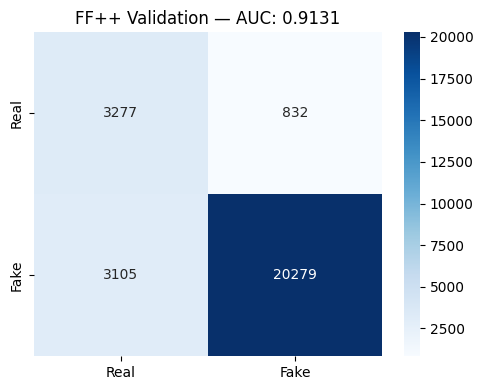


CelebDF Validation:
  Accuracy: 0.9245
  AUC-ROC:  0.9820
              precision    recall  f1-score   support

        Real       0.96      0.86      0.91      1285
        Fake       0.90      0.97      0.94      1683

    accuracy                           0.92      2968
   macro avg       0.93      0.92      0.92      2968
weighted avg       0.93      0.92      0.92      2968



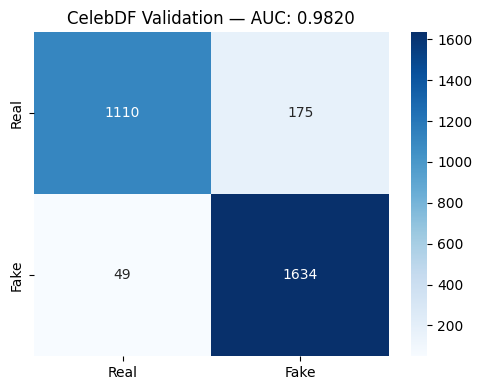

  CelebDF: 14840 (Real:6340 Fake:8500)

CelebDF Full:
  Accuracy: 0.9338
  AUC-ROC:  0.9865
              precision    recall  f1-score   support

        Real       0.97      0.88      0.92      6340
        Fake       0.91      0.98      0.94      8500

    accuracy                           0.93     14840
   macro avg       0.94      0.93      0.93     14840
weighted avg       0.94      0.93      0.93     14840



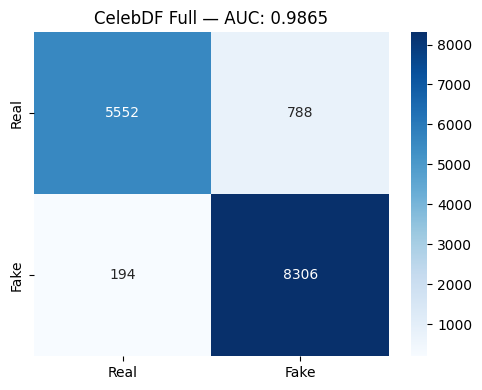


SUMMARY
  FF++ Val:      Acc=0.8568  AUC=0.9131
  CelebDF Val:   Acc=0.9245  AUC=0.9820
  CelebDF Full:  Acc=0.9338  AUC=0.9865


In [3]:
# CELL 3: EVALUATE ON EACH DATASET SEPARATELY

import seaborn as sns

# Reload best model
model_eval = CLIPDetector_v4(unfreeze_last_n=4).to(DEVICE)
ckpt = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=False)
model_eval.load_state_dict(ckpt["model_state"])
model_eval.eval()
print(f"Model loaded. Val AUC: {ckpt['val_auc']:.4f}")

def eval_dataset(loader, name):
    preds, labs, probs_l = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            logits, _ = model_eval(imgs.to(DEVICE))
            p = F.softmax(logits, dim=1)
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(labels.numpy())
            probs_l.extend(p[:, FAKE].cpu().numpy())
    acc = accuracy_score(labs, preds)
    auc = roc_auc_score(labs, probs_l)
    cm = confusion_matrix(labs, preds)
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  AUC-ROC:  {auc:.4f}")
    print(classification_report(labs, preds, target_names=["Real","Fake"]))
    # Plot
    fig, ax = plt.subplots(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Real","Fake"], yticklabels=["Real","Fake"], ax=ax)
    ax.set_title(f"{name} — AUC: {auc:.4f}")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"cm_{name.replace(' ','_').lower()}.png"), dpi=150)
    plt.show()
    return acc, auc

# Test on FF++ val
ff_val_loader = DataLoader(
    FFDataset(FF_VAL, val_tf), batch_size=32, shuffle=False, num_workers=4
)
ff_acc, ff_auc = eval_dataset(ff_val_loader, "FF++ Validation")

# Test on CelebDF val (the 20% held-out split)
celeb_val_loader = DataLoader(celeb_val, batch_size=32, shuffle=False, num_workers=4)
celeb_acc, celeb_auc = eval_dataset(celeb_val_loader, "CelebDF Validation")

# Test on ALL CelebDF (to see overall performance)
celeb_all_eval = CelebDataset(CELEB_DATA, val_tf)
celeb_all_loader = DataLoader(celeb_all_eval, batch_size=32, shuffle=False, num_workers=4)
celeb_all_acc, celeb_all_auc = eval_dataset(celeb_all_loader, "CelebDF Full")

print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"  FF++ Val:      Acc={ff_acc:.4f}  AUC={ff_auc:.4f}")
print(f"  CelebDF Val:   Acc={celeb_acc:.4f}  AUC={celeb_auc:.4f}")
print(f"  CelebDF Full:  Acc={celeb_all_acc:.4f}  AUC={celeb_all_auc:.4f}")

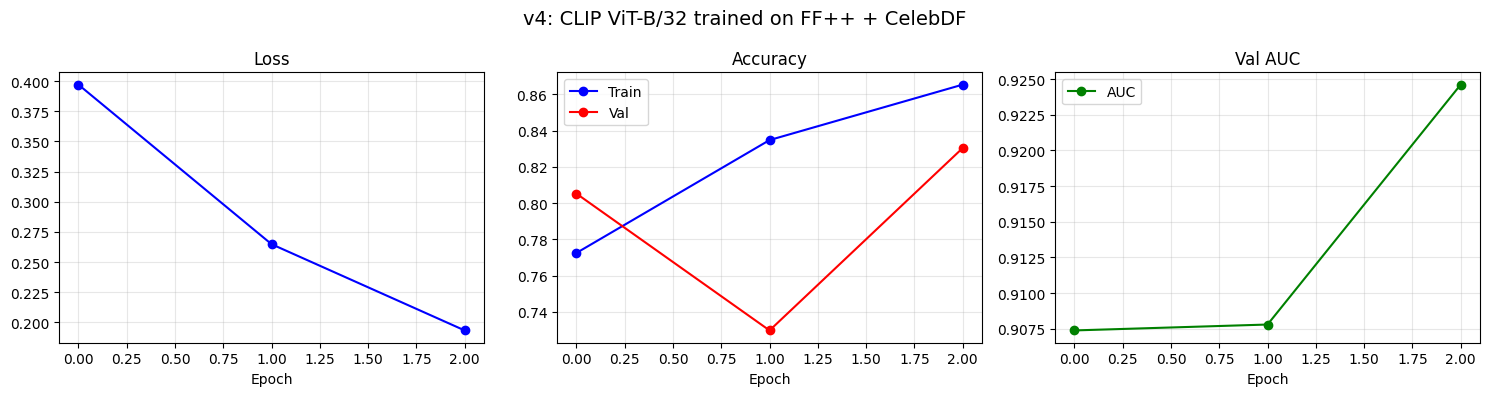

All saved to: /teamspace/studios/this_studio/models_v4

Download to your local project:
  /teamspace/studios/this_studio/models_v4/clip_detector_v4.pth -> models/clip_detector.pth

Rename clip_detector_v4.pth to clip_detector.pth so app.py detects it.

{
  "model": "CLIP ViT-B/32 (last 4 layers unfrozen)",
  "img_size": 224,
  "classes": [
    "real",
    "fake"
  ],
  "trained_on": "FaceForensics++ C23 + CelebDF-v2 (combined)",
  "val_auc_roc": 0.9246,
  "epochs": 8,
  "batch_size": 16,
  "learning_rate": 2e-05,
  "ff_val_auc": 0.9142,
  "celeb_val_auc": 0.9764,
  "celeb_full_auc": 0.982
}


In [4]:
# CELL 4: EXPORT

# Training curves
ckpt = torch.load(SAVE_PATH, map_location="cpu", weights_only=False)
h = ckpt["hist"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(h["loss"], 'b-o'); axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)
axes[1].plot(h["train_acc"], 'b-o', label="Train"); axes[1].plot(h["val_acc"], 'r-o', label="Val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(h["val_auc"], 'g-o', label="AUC"); axes[2].set_title("Val AUC"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(alpha=0.3)
plt.suptitle("v4: CLIP ViT-B/32 trained on FF++ + CelebDF", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves_v4.png"), dpi=150)
plt.show()

# Model info
info = {
    "model": "CLIP ViT-B/32 (last 4 layers unfrozen)",
    "img_size": 224,
    "classes": ["real", "fake"],
    "trained_on": "FaceForensics++ C23 + CelebDF-v2 (combined)",
    "val_auc_roc": round(ckpt["val_auc"], 4),
    "epochs": 8,
    "batch_size": 16,
    "learning_rate": 2e-5,
}

try:
    info["ff_val_auc"] = round(ff_auc, 4)
    info["celeb_val_auc"] = round(celeb_auc, 4)
    info["celeb_full_auc"] = round(celeb_all_auc, 4)
except:
    pass

with open(os.path.join(SAVE_DIR, "model_info_v4.json"), "w") as f:
    json.dump(info, f, indent=2)

print("All saved to:", SAVE_DIR)
print()
print("Download to your local project:")
print(f"  {SAVE_DIR}/clip_detector_v4.pth -> models/clip_detector.pth")
print()
print("Rename clip_detector_v4.pth to clip_detector.pth so app.py detects it.")
print()
print(json.dumps(info, indent=2))

In [4]:
import os
for_fake = "/teamspace/studios/this_studio/for_data/for-2sec/for-2seconds/testing/fake"
files = os.listdir(for_fake)[:5]
for f in files:
    print(f"  {f}")

  file100.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
  file1000.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
  file1001.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
  file1004.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
  file1005.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav


In [5]:
import shutil, os

src_fake = "/teamspace/studios/this_studio/for_data/for-2sec/for-2seconds/testing/fake"
src_real = "/teamspace/studios/this_studio/for_data/for-2sec/for-2seconds/testing/real"
dst = "/teamspace/studios/this_studio/audio_test_samples"
os.makedirs(dst, exist_ok=True)

# Copy 5 fake + 5 real audio files
for f in sorted(os.listdir(src_fake))[:5]:
    shutil.copy(os.path.join(src_fake, f), os.path.join(dst, f"FAKE_{f}"))

for f in sorted(os.listdir(src_real))[:5]:
    shutil.copy(os.path.join(src_real, f), os.path.join(dst, f"REAL_{f}"))

for f in sorted(os.listdir(dst)):
    size = os.path.getsize(os.path.join(dst, f)) / 1024
    print(f"  {f:40s} {size:.0f} KB")

  FAKE_file100.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav 63 KB
  FAKE_file1000.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav 63 KB
  FAKE_file1001.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav 63 KB
  FAKE_file1004.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav 63 KB
  FAKE_file1005.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav 63 KB
  REAL_file10.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav 63 KB
  REAL_file1006.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav 63 KB
  REAL_file1009.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav 63 KB
  REAL_file1010.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav 63 KB
  REAL_file1022.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav 63 KB


In [2]:
!pip install torch torchvision transformers facenet-pytorch -q
!pip install transformers==4.40.0 -q
!pip install torch==2.2.2 transformers==4.38.0 huggingface_hub==0.21.0 facenet-pytorch -q

In [3]:
import torch, torch.nn as nn, torch.nn.functional as F, os, random
from PIL import Image
from torchvision import transforms
from transformers import CLIPModel
import numpy as np
from facenet_pytorch import MTCNN

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]
val_tf = transforms.Compose([transforms.Resize(224), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(CLIP_MEAN, CLIP_STD)])

class CLIPDetector_v4(nn.Module):
    def __init__(self, name="openai/clip-vit-base-patch32", unfreeze_last_n=4):
        super().__init__()
        self.vision_encoder = CLIPModel.from_pretrained(name).vision_model
        self.feat_dim = self.vision_encoder.config.hidden_size
        for p in self.vision_encoder.parameters(): p.requires_grad = False
        num_layers = len(self.vision_encoder.encoder.layers)
        for i in range(num_layers - unfreeze_last_n, num_layers):
            for p in self.vision_encoder.encoder.layers[i].parameters(): p.requires_grad = True
        for p in self.vision_encoder.post_layernorm.parameters(): p.requires_grad = True
        self.classifier = nn.Linear(self.feat_dim, 2)
    def forward(self, x):
        feat = F.normalize(self.vision_encoder(pixel_values=x).pooler_output, p=2, dim=-1)
        return self.classifier(feat), feat

model = CLIPDetector_v4(unfreeze_last_n=4).to(DEVICE)
ckpt = torch.load("/teamspace/studios/this_studio/models_v4/clip_detector_v4.pth", map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()

mtcnn_test = MTCNN(keep_all=True, device=DEVICE, post_process=False)
print("Ready")

Ready


In [5]:
from facenet_pytorch import MTCNN
import numpy as np

mtcnn_test = MTCNN(keep_all=True, device=DEVICE, post_process=False)
real_dir = "/teamspace/studios/this_studio/celebdf/frames/real"

import random
random.seed(99)
test_files = random.sample(os.listdir(real_dir), 20)

whole_correct = 0
face_correct = 0

for f in test_files:
    img = Image.open(os.path.join(real_dir, f)).convert("RGB")
    
    # Whole image
    t = val_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(t)[0], dim=1)[0]
    whole_rp = probs[0].item()
    if whole_rp > 0.5: whole_correct += 1
    
    # Face crop
    boxes, _ = mtcnn_test.detect(img)
    if boxes is not None and len(boxes) > 0:
        areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
        box = boxes[int(np.argmax(areas))]
        x1,y1,x2,y2 = [int(b) for b in box]; pad=40
        face = img.crop((max(0,x1-pad),max(0,y1-pad),min(img.width,x2+pad),min(img.height,y2+pad)))
        t2 = val_tf(face).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs2 = torch.softmax(model(t2)[0], dim=1)[0]
        face_rp = probs2[0].item()
        if face_rp > 0.5: face_correct += 1
        print(f"  {f:30s} whole_real={whole_rp:.3f} face_real={face_rp:.3f}")
    else:
        face_correct += 1  # no face = use whole
        print(f"  {f:30s} whole_real={whole_rp:.3f} NO FACE")

print(f"\nWhole image: {whole_correct}/20")
print(f"Face crop:   {face_correct}/20")

  id27_0003_f84.jpg              whole_real=0.932 face_real=0.915
  id24_0007_f92.jpg              whole_real=0.941 face_real=0.940
  00238_f84.jpg                  whole_real=0.968 face_real=0.905
  id48_0005_f0.jpg               whole_real=0.941 face_real=0.948
  00215_f281.jpg                 whole_real=0.948 face_real=0.100
  00274_f368.jpg                 whole_real=0.967 face_real=0.953
  00292_f315.jpg                 whole_real=0.960 face_real=0.825
  00152_f139.jpg                 whole_real=0.962 face_real=0.935
  id8_0007_f232.jpg              whole_real=0.918 face_real=0.908
  00099_f98.jpg                  whole_real=0.957 face_real=0.277
  00295_f405.jpg                 whole_real=0.956 face_real=0.947
  id61_0005_f174.jpg             whole_real=0.942 face_real=0.931
  id24_0009_f62.jpg              whole_real=0.958 face_real=0.830
  id3_0003_f37.jpg               whole_real=0.936 face_real=0.903
  id57_0002_f250.jpg             whole_real=0.913 face_real=0.894
  id59_000

Video 023 frame count: 30
Video 032 frame count: 30
Other video frame count: 4049

Metric          023 (all wrong) 032 (all wrong) Others (normal)
size                    224x224         224x224         224x224
brightness                 84.3           110.5            71.5
sharpness                 268.4           588.5           369.5
saturation                 17.0            22.0            14.8
blockiness                 1.05           1.041           1.026
left_bar_px                 0.0             0.0             0.0

Lower brightness = darker, lower sharpness = more blurry,
higher blockiness = heavier compression, left_bar = left black bar pixels


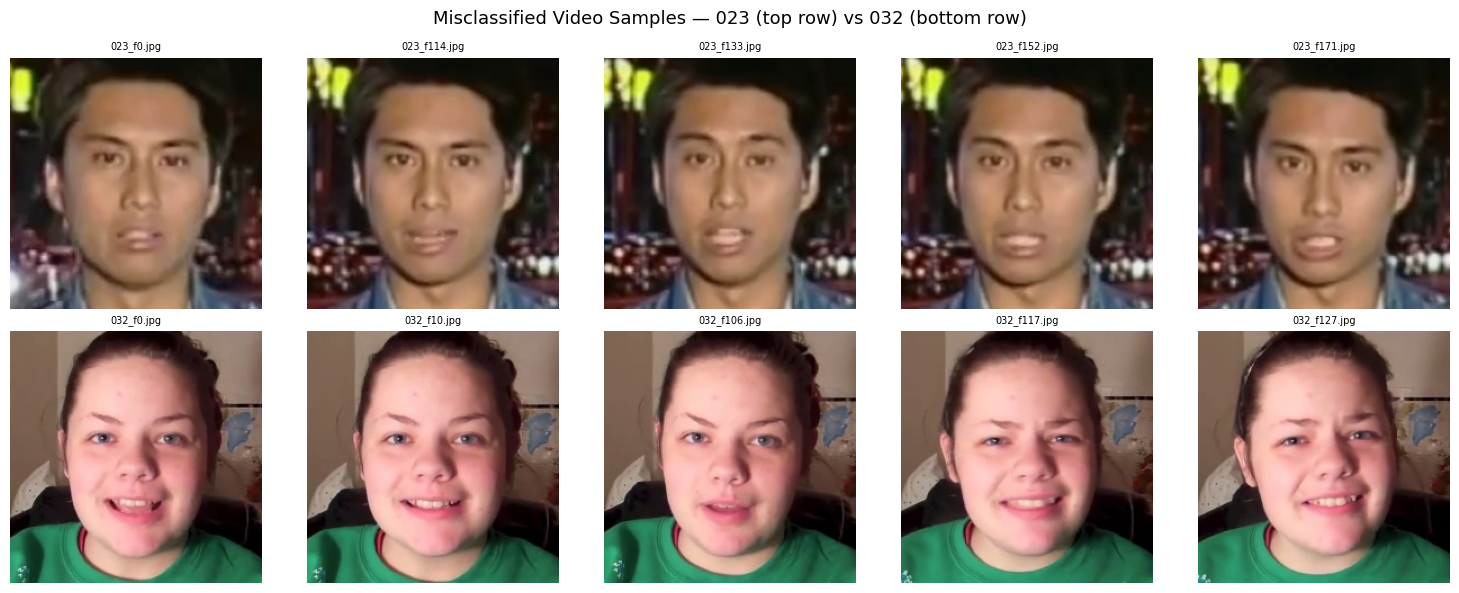


Image saved to misclassified_videos.png

Look at which metric differs most between 023/032 and 'Others' — that is the root cause.


In [2]:
# ============================================================
# Diagnose why videos 023 and 032 are misclassified
# ============================================================
import os
import numpy as np
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Change to your real folder path
REAL_DIR = "/teamspace/studios/this_studio/ff_data/dataset_processed_split/val/Real"

def analyze_image(path):
    img = Image.open(path).convert("RGB")
    arr = np.array(img).astype(np.float32)
    h, w = arr.shape[:2]

    # Black bar detection
    left_bar = sum(1 for col in range(w) if np.mean(arr[:, col, :]) < 10)
    right_bar = sum(1 for col in range(w-1, -1, -1) if np.mean(arr[:, col, :]) < 10)

    # Brightness
    brightness = float(np.mean(arr))

    # Sharpness (Laplacian variance — lower means more blurry)
    gray = img.convert("L")
    lap = np.array(gray.filter(ImageFilter.FIND_EDGES)).astype(np.float32)
    sharpness = float(np.var(lap))

    # Colour saturation
    r, g, b = arr[:,:,0], arr[:,:,1], arr[:,:,2]
    saturation = float(np.mean(np.std([r, g, b], axis=0)))

    # Compression blockiness
    gray_arr = np.mean(arr, axis=2)
    block_diffs = [np.mean(np.abs(gray_arr[i,:] - gray_arr[i-1,:])) for i in range(8, h, 8)]
    nonblock_diffs = [np.mean(np.abs(gray_arr[i,:] - gray_arr[i-1,:])) for i in range(1, h) if i % 8 != 0]
    blockiness = np.mean(block_diffs) / max(np.mean(nonblock_diffs), 0.001)

    return {
        "size": f"{w}x{h}",
        "brightness": round(brightness, 1),
        "sharpness": round(sharpness, 1),
        "saturation": round(saturation, 1),
        "blockiness": round(blockiness, 3),
        "left_bar_px": left_bar,
        "right_bar_px": right_bar,
    }

# ── Find frames from videos 023 and 032 ──────────────────────────────
all_files = sorted(os.listdir(REAL_DIR))
files_023 = [f for f in all_files if f.startswith("023_")]
files_032 = [f for f in all_files if f.startswith("032_")]
other_files = [f for f in all_files if not f.startswith("023_") and not f.startswith("032_")]

print(f"Video 023 frame count: {len(files_023)}")
print(f"Video 032 frame count: {len(files_032)}")
print(f"Other video frame count: {len(other_files)}")

# ── Analyse statistical features for each group ──────────────────────
def stats_for_group(files, folder, n=30):
    results = []
    for f in files[:n]:
        try:
            s = analyze_image(os.path.join(folder, f))
            results.append(s)
        except:
            pass
    if not results:
        return {}
    return {
        "brightness":  round(np.mean([r["brightness"]  for r in results]), 1),
        "sharpness":   round(np.mean([r["sharpness"]   for r in results]), 1),
        "saturation":  round(np.mean([r["saturation"]  for r in results]), 1),
        "blockiness":  round(np.mean([r["blockiness"]  for r in results]), 3),
        "left_bar_px": round(np.mean([r["left_bar_px"] for r in results]), 1),
        "size": results[0]["size"],
        "n": len(results),
    }

s023   = stats_for_group(files_023,   REAL_DIR)
s032   = stats_for_group(files_032,   REAL_DIR)
sother = stats_for_group(other_files, REAL_DIR)

print("\n" + "="*60)
print(f"{'Metric':<15} {'023 (all wrong)':>15} {'032 (all wrong)':>15} {'Others (normal)':>15}")
print("="*60)
for key in ["size", "brightness", "sharpness", "saturation", "blockiness", "left_bar_px"]:
    v023   = str(s023.get(key,   "N/A"))
    v032   = str(s032.get(key,   "N/A"))
    vother = str(sother.get(key, "N/A"))
    print(f"{key:<15} {v023:>15} {v032:>15} {vother:>15}")
print("="*60)
print("\nLower brightness = darker, lower sharpness = more blurry,")
print("higher blockiness = heavier compression, left_bar = left black bar pixels")

# ── Show sample frames from videos 023 and 032 ───────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Misclassified Video Samples — 023 (top row) vs 032 (bottom row)", fontsize=13)

for i, f in enumerate(files_023[:5]):
    try:
        img = Image.open(os.path.join(REAL_DIR, f)).convert("RGB")
        axes[0, i].imshow(img)
        axes[0, i].set_title(f, fontsize=7)
        axes[0, i].axis("off")
    except:
        axes[0, i].axis("off")

for i, f in enumerate(files_032[:5]):
    try:
        img = Image.open(os.path.join(REAL_DIR, f)).convert("RGB")
        axes[1, i].imshow(img)
        axes[1, i].set_title(f, fontsize=7)
        axes[1, i].axis("off")
    except:
        axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("misclassified_videos.png", dpi=120)
plt.show()
print("\nImage saved to misclassified_videos.png")
print("\nLook at which metric differs most between 023/032 and 'Others' — that is the root cause.")

Model loaded | val_auc=0.9246159225422697
Found 27493 images: 4109 real, 23384 fake
  ... 50/400
  ... 100/400
  ... 150/400
  ... 200/400
  ... 250/400
  ... 300/400
  ... 350/400
  ... 400/400

Evaluated 400 images, 26 errors

  ACCURACY REPORT
  Overall  : 93.5%  (374/400)
  Real     : 87.5%  (175/200)
  Fake     : 99.5%  (199/200)

              precision    recall  f1-score   support

        REAL       0.99      0.88      0.93       200
        FAKE       0.89      0.99      0.94       200

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.93       400
weighted avg       0.94      0.94      0.93       400


Misclassified images (26 total):

  Real images predicted as FAKE (25 images):
    023_f0.jpg                          fake=83.9%
    023_f152.jpg                        fake=52.0%
    023_f190.jpg                        fake=60.7%
    023_f209.jpg                        fake=67.7%
    023_f304.jpg                        fake=77.6%


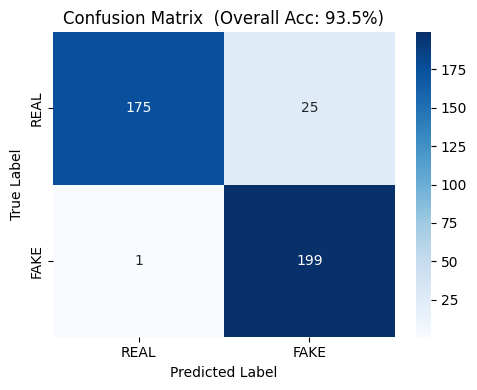


Confusion matrix saved to eval_confusion_matrix.png


In [10]:
import os, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from PIL import Image
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Configure paths (change to your actual paths) ─────────────────
MODEL_PATH = "/teamspace/studios/this_studio/models_v4/clip_detector_v4.pth"
REAL_DIR   = "/teamspace/studios/this_studio/ff_data/dataset_processed_split/val/Real"
FAKE_DIR   = "/teamspace/studios/this_studio/ff_data/dataset_processed_split/val"  # will auto-find all fake subfolders

# If you have a separate test set, change to test set paths:
# REAL_DIR = "/teamspace/studios/this_studio/test_images/real"
# FAKE_DIR = "/teamspace/studios/this_studio/test_images/fake"

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
LABEL_REAL, LABEL_FAKE = 0, 1
FAKE_FOLDERS = {'FaceShifter','FaceSwap','DeepFakeDetection','NeuralTextures','Deepfakes','Face2Face'}

CLIP_MEAN = [0.48145466, 0.4578275,  0.40821073]
CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]

val_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])

# ── 2. Load model ─────────────────────────────────────────────────────
from transformers import CLIPModel

class CLIPDeepfakeDetector(nn.Module):
    def __init__(self, name="openai/clip-vit-base-patch32", unfreeze_last_n=4):
        super().__init__()
        self.vision_encoder = CLIPModel.from_pretrained(name).vision_model
        self.feat_dim = self.vision_encoder.config.hidden_size
        for p in self.vision_encoder.parameters(): p.requires_grad = False
        num_layers = len(self.vision_encoder.encoder.layers)
        for i in range(num_layers - unfreeze_last_n, num_layers):
            for p in self.vision_encoder.encoder.layers[i].parameters(): p.requires_grad = True
        for p in self.vision_encoder.post_layernorm.parameters(): p.requires_grad = True
        self.classifier = nn.Linear(self.feat_dim, 2)
    def forward(self, x):
        feat = F.normalize(self.vision_encoder(pixel_values=x).pooler_output, p=2, dim=-1)
        return self.classifier(feat), feat

model = CLIPDeepfakeDetector().to(DEVICE)
ckpt  = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"] if "model_state" in ckpt else ckpt)
model.eval()
print(f"Model loaded | val_auc={ckpt.get('val_auc', 'N/A')}")

# ── 3. Prior correction (fix imbalance from 2:1 fake:real training set) ──
def correct_prior(fp, rp, prior_fake=2/3, prior_real=1/3):
    cf = fp / prior_fake
    cr = rp / prior_real
    t  = cf + cr
    return cf / t, cr / t

# ── 4. Strip black bars (remove black borders from video frames) ──────
def strip_black_bars(img_pil, threshold=10):
    arr = np.array(img_pil)
    h, w = arr.shape[:2]
    left = 0
    for col in range(w):
        if np.mean(arr[:, col, :]) < threshold: left = col + 1
        else: break
    right = w
    for col in range(w-1, -1, -1):
        if np.mean(arr[:, col, :]) < threshold: right = col
        else: break
    top = 0
    for row in range(h):
        if np.mean(arr[row, :, :]) < threshold: top = row + 1
        else: break
    bottom = h
    for row in range(h-1, -1, -1):
        if np.mean(arr[row, :, :]) < threshold: bottom = row
        else: break
    if left > w*0.01 or right < w*0.99 or top > h*0.01 or bottom < h*0.99:
        return img_pil.crop((left, top, right, bottom))
    return img_pil

# ── 5. Single image prediction ────────────────────────────────────────
def predict_one(img_pil):
    img_pil = strip_black_bars(img_pil)
    t = val_tf(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits, _ = model(t)
        probs = F.softmax(logits, dim=1)[0]
    rp, fp = probs[LABEL_REAL].item(), probs[LABEL_FAKE].item()
    fp, rp = correct_prior(fp, rp)
    return ("FAKE" if fp > rp else "REAL"), fp, rp

# ── 6. Collect test image paths ───────────────────────────────────────
SUPPORTED = ('.jpg', '.jpeg', '.png')

def collect_samples(real_dir, fake_dir):
    samples = []  # (path, true_label)

    # Real
    if os.path.isdir(real_dir):
        for f in sorted(os.listdir(real_dir)):
            if f.lower().endswith(SUPPORTED):
                samples.append((os.path.join(real_dir, f), "REAL"))
    else:
        print(f"WARNING: REAL dir not found: {real_dir}")

    # Fake — supports both flat folder and FF++ subfolder structure
    if os.path.isdir(fake_dir):
        subdirs = [d for d in os.listdir(fake_dir) if os.path.isdir(os.path.join(fake_dir, d))]
        fake_subdirs = [d for d in subdirs if d in FAKE_FOLDERS]

        if fake_subdirs:
            # FF++ structure: fake_dir/Deepfakes/*.jpg etc.
            for sub in fake_subdirs:
                subpath = os.path.join(fake_dir, sub)
                for f in sorted(os.listdir(subpath)):
                    if f.lower().endswith(SUPPORTED):
                        samples.append((os.path.join(subpath, f), "FAKE"))
        else:
            # Flat folder: all images are fake
            for f in sorted(os.listdir(fake_dir)):
                if f.lower().endswith(SUPPORTED):
                    samples.append((os.path.join(fake_dir, f), "FAKE"))
    else:
        print(f"WARNING: FAKE dir not found: {fake_dir}")

    return samples

samples = collect_samples(REAL_DIR, FAKE_DIR)
real_count = sum(1 for _, l in samples if l == "REAL")
fake_count = sum(1 for _, l in samples if l == "FAKE")
print(f"Found {len(samples)} images: {real_count} real, {fake_count} fake")

# ── 7. Run evaluation ─────────────────────────────────────────────────
# Limit to MAX_PER_CLASS images per class to avoid long runtime; set to None for all
MAX_PER_CLASS = 200

real_samples = [(p, l) for p, l in samples if l == "REAL"][:MAX_PER_CLASS]
fake_samples = [(p, l) for p, l in samples if l == "FAKE"][:MAX_PER_CLASS]
eval_samples = real_samples + fake_samples

y_true, y_pred = [], []
errors = []

for i, (path, true_label) in enumerate(eval_samples):
    try:
        img = Image.open(path).convert("RGB")
        pred_label, fp, rp = predict_one(img)
        y_true.append(true_label)
        y_pred.append(pred_label)
        if pred_label != true_label:
            errors.append({
                "file": os.path.basename(path),
                "true": true_label,
                "pred": pred_label,
                "fake_prob": round(fp*100, 1),
                "real_prob": round(rp*100, 1),
            })
    except Exception as e:
        print(f"  ! {os.path.basename(path)}: {e}")

    if (i+1) % 50 == 0:
        print(f"  ... {i+1}/{len(eval_samples)}")

print(f"\nEvaluated {len(y_true)} images, {len(errors)} errors")

# ── 8. Results summary ────────────────────────────────────────────────
real_true  = [t for t, p in zip(y_true, y_pred) if t == "REAL"]
real_pred  = [p for t, p in zip(y_true, y_pred) if t == "REAL"]
fake_true  = [t for t, p in zip(y_true, y_pred) if t == "FAKE"]
fake_pred  = [p for t, p in zip(y_true, y_pred) if t == "FAKE"]

real_acc = sum(1 for t, p in zip(real_true, real_pred) if t == p) / max(len(real_true), 1)
fake_acc = sum(1 for t, p in zip(fake_true, fake_pred) if t == p) / max(len(fake_true), 1)
overall  = sum(1 for t, p in zip(y_true, y_pred) if t == p) / max(len(y_true), 1)

print("\n" + "="*50)
print("  ACCURACY REPORT")
print("="*50)
print(f"  Overall  : {overall*100:.1f}%  ({sum(t==p for t,p in zip(y_true,y_pred))}/{len(y_true)})")
print(f"  Real     : {real_acc*100:.1f}%  ({sum(t==p for t,p in zip(real_true,real_pred))}/{len(real_true)})")
print(f"  Fake     : {fake_acc*100:.1f}%  ({sum(t==p for t,p in zip(fake_true,fake_pred))}/{len(fake_true)})")
print()
print(classification_report(y_true, y_pred, labels=["REAL","FAKE"], target_names=["REAL","FAKE"]))
print("="*50)

# ── 9. List of misclassified images ──────────────────────────────────
if errors:
    print(f"\nMisclassified images ({len(errors)} total):")
    real_errors = [e for e in errors if e["true"] == "REAL"]
    fake_errors = [e for e in errors if e["true"] == "FAKE"]
    if real_errors:
        print(f"\n  Real images predicted as FAKE ({len(real_errors)} images):")
        for e in real_errors[:20]:
            print(f"    {e['file']:<35} fake={e['fake_prob']}%")
    if fake_errors:
        print(f"\n  Fake images predicted as REAL ({len(fake_errors)} images):")
        for e in fake_errors[:20]:
            print(f"    {e['file']:<35} fake={e['fake_prob']}%")

# ── 10. Confusion matrix plot ─────────────────────────────────────────
labels = ["REAL", "FAKE"]
cm = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title(f"Confusion Matrix  (Overall Acc: {overall*100:.1f}%)")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("eval_confusion_matrix.png", dpi=150)
plt.show()
print("\nConfusion matrix saved to eval_confusion_matrix.png")

Model loaded
14840 images loaded from CelebDF-v2
  ... 500/14840
  ... 1000/14840
  ... 1500/14840
  ... 2000/14840
  ... 2500/14840
  ... 3000/14840
  ... 3500/14840
  ... 4000/14840
  ... 4500/14840
  ... 5000/14840
  ... 5500/14840
  ... 6000/14840
  ... 6500/14840
  ... 7000/14840
  ... 7500/14840
  ... 8000/14840
  ... 8500/14840
  ... 9000/14840
  ... 9500/14840
  ... 10000/14840
  ... 10500/14840
  ... 11000/14840
  ... 11500/14840
  ... 12000/14840
  ... 12500/14840
  ... 13000/14840
  ... 13500/14840
  ... 14000/14840
  ... 14500/14840


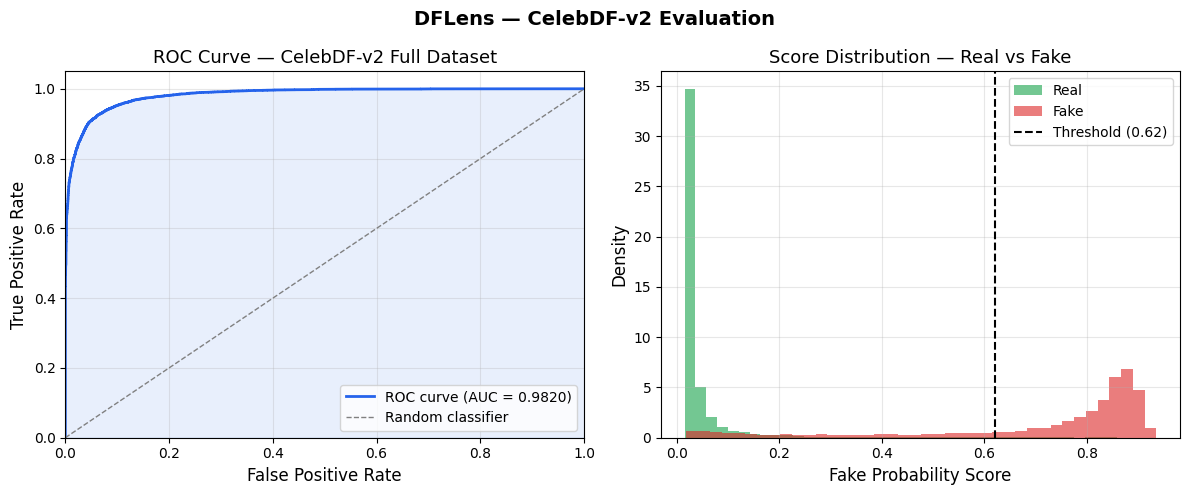


AUC-ROC: 0.9820
Saved to /teamspace/studios/this_studio/models_v4/roc_curve_celebdf.png


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from sklearn.metrics import roc_curve, auc

# Configuration
MODEL_PATH = "/teamspace/studios/this_studio/models_v4/clip_detector_v4.pth"
CELEB_DIR  = "/teamspace/studios/this_studio/celebdf/frames"
SAVE_DIR   = "/teamspace/studios/this_studio/models_v4"

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
LABEL_REAL, LABEL_FAKE = 0, 1
CLIP_MEAN = [0.48145466, 0.4578275,  0.40821073]
CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]
SUPPORTED = ('.jpg', '.jpeg', '.png')

val_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])

# Load model
from transformers import CLIPModel

class CLIPDeepfakeDetector(nn.Module):
    def __init__(self, name="openai/clip-vit-base-patch32", unfreeze_last_n=4):
        super().__init__()
        self.vision_encoder = CLIPModel.from_pretrained(name).vision_model
        self.feat_dim = self.vision_encoder.config.hidden_size
        for p in self.vision_encoder.parameters(): p.requires_grad = False
        num_layers = len(self.vision_encoder.encoder.layers)
        for i in range(num_layers - unfreeze_last_n, num_layers):
            for p in self.vision_encoder.encoder.layers[i].parameters(): p.requires_grad = True
        for p in self.vision_encoder.post_layernorm.parameters(): p.requires_grad = True
        self.classifier = nn.Linear(self.feat_dim, 2)
    def forward(self, x):
        feat = F.normalize(self.vision_encoder(pixel_values=x).pooler_output, p=2, dim=-1)
        return self.classifier(feat), feat

model = CLIPDeepfakeDetector().to(DEVICE)
ckpt  = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"] if "model_state" in ckpt else ckpt)
model.eval()
print(f"Model loaded")

# Prior correction
def correct_prior(fp, rp, prior_fake=2/3, prior_real=1/3):
    cf = fp / prior_fake
    cr = rp / prior_real
    t  = cf + cr
    return cf / t, cr / t

# Collect CelebDF samples
samples = []
for cls in ['real', 'fake']:
    label = 0 if cls == 'real' else 1
    folder = os.path.join(CELEB_DIR, cls)
    for f in sorted(os.listdir(folder)):
        if f.lower().endswith(SUPPORTED):
            samples.append((os.path.join(folder, f), label))

print(f"{len(samples)} images loaded from CelebDF-v2")

# Run inference
y_true, y_scores = [], []

for i, (path, label) in enumerate(samples):
    try:
        img = Image.open(path).convert("RGB")
        t = val_tf(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits, _ = model(t)
            probs = F.softmax(logits, dim=1)[0]
        rp, fp = probs[LABEL_REAL].item(), probs[LABEL_FAKE].item()
        fp, rp = correct_prior(fp, rp)
        y_true.append(label)
        y_scores.append(fp)
    except: pass
    if (i+1) % 500 == 0:
        print(f"  ... {i+1}/{len(samples)}")

y_true   = np.array(y_true)
y_scores = np.array(y_scores)

# Plot
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc     = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#2563eb', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0,1], [0,1], color='gray', lw=1, linestyle='--', label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2563eb')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — CelebDF-v2 Full Dataset', fontsize=13)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# Score distribution
real_scores = y_scores[y_true == 0]
fake_scores = y_scores[y_true == 1]
axes[1].hist(real_scores, bins=40, alpha=0.6, color='#16a34a', label='Real', density=True)
axes[1].hist(fake_scores, bins=40, alpha=0.6, color='#dc2626', label='Fake', density=True)
axes[1].axvline(x=0.62, color='black', linestyle='--', lw=1.5, label='Threshold (0.62)')
axes[1].set_xlabel('Fake Probability Score', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Score Distribution — Real vs Fake', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('DFLens — CelebDF-v2 Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "roc_curve_celebdf.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nAUC-ROC: {roc_auc:.4f}")
print(f"Saved to {SAVE_DIR}/roc_curve_celebdf.png")

Model loaded
27493 total images
  ... 1000/27493
  ... 2000/27493
  ... 3000/27493
  ... 4000/27493
  ... 5000/27493
  ... 6000/27493
  ... 7000/27493
  ... 8000/27493
  ... 9000/27493
  ... 10000/27493
  ... 11000/27493
  ... 12000/27493
  ... 13000/27493
  ... 14000/27493
  ... 15000/27493
  ... 16000/27493
  ... 17000/27493
  ... 18000/27493
  ... 19000/27493
  ... 20000/27493
  ... 21000/27493
  ... 22000/27493
  ... 23000/27493
  ... 24000/27493
  ... 25000/27493
  ... 26000/27493
  ... 27000/27493


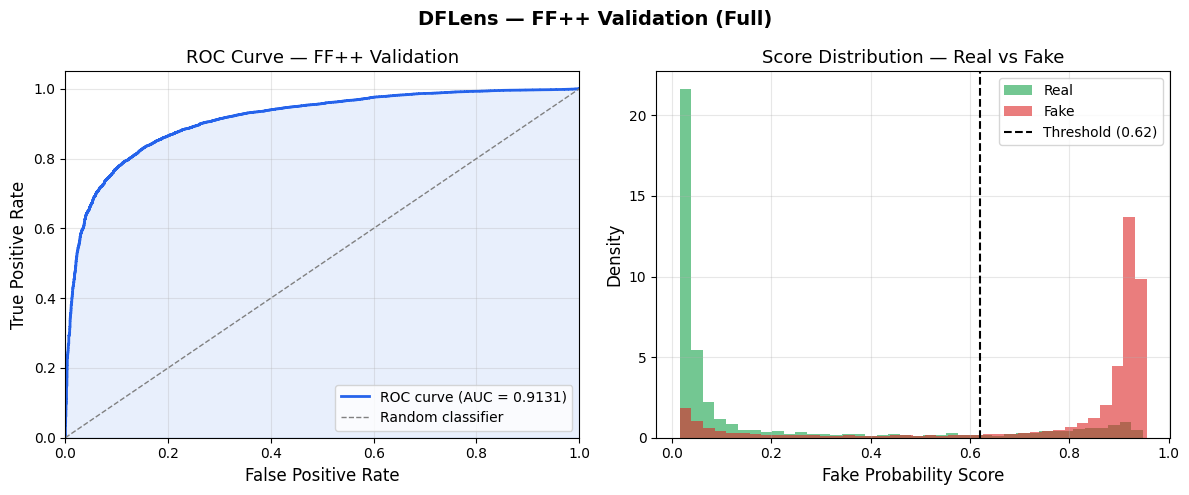


AUC-ROC: 0.9131
Saved to /teamspace/studios/this_studio/models_v4/roc_curve_ffpp_full.png


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from sklearn.metrics import roc_curve, auc
from torch.utils.data import Dataset, DataLoader

# Configuration
MODEL_PATH = "/teamspace/studios/this_studio/models_v4/clip_detector_v4.pth"
REAL_DIR   = "/teamspace/studios/this_studio/ff_data/dataset_processed_split/val/Real"
FAKE_DIR   = "/teamspace/studios/this_studio/ff_data/dataset_processed_split/val"
SAVE_DIR   = "/teamspace/studios/this_studio/models_v4"

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
LABEL_REAL, LABEL_FAKE = 0, 1
FAKE_FOLDERS = {'FaceShifter','FaceSwap','DeepFakeDetection','NeuralTextures','Deepfakes','Face2Face'}
CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]
SUPPORTED = ('.jpg', '.jpeg', '.png')

val_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])

# Load model
from transformers import CLIPModel

class CLIPDeepfakeDetector(nn.Module):
    def __init__(self, name="openai/clip-vit-base-patch32", unfreeze_last_n=4):
        super().__init__()
        self.vision_encoder = CLIPModel.from_pretrained(name).vision_model
        self.feat_dim = self.vision_encoder.config.hidden_size
        for p in self.vision_encoder.parameters(): p.requires_grad = False
        num_layers = len(self.vision_encoder.encoder.layers)
        for i in range(num_layers - unfreeze_last_n, num_layers):
            for p in self.vision_encoder.encoder.layers[i].parameters(): p.requires_grad = True
        for p in self.vision_encoder.post_layernorm.parameters(): p.requires_grad = True
        self.classifier = nn.Linear(self.feat_dim, 2)
    def forward(self, x):
        feat = F.normalize(self.vision_encoder(pixel_values=x).pooler_output, p=2, dim=-1)
        return self.classifier(feat), feat

model = CLIPDeepfakeDetector().to(DEVICE)
ckpt  = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"] if "model_state" in ckpt else ckpt)
model.eval()
print(f"Model loaded")

def correct_prior(fp, rp, prior_fake=2/3, prior_real=1/3):
    cf = fp / prior_fake
    cr = rp / prior_real
    t  = cf + cr
    return cf / t, cr / t

# Collect ALL FF++ validation samples
samples = []
for f in sorted(os.listdir(REAL_DIR)):
    if f.lower().endswith(SUPPORTED):
        samples.append((os.path.join(REAL_DIR, f), 0))

for sub in FAKE_FOLDERS:
    subpath = os.path.join(FAKE_DIR, sub)
    if os.path.isdir(subpath):
        for f in sorted(os.listdir(subpath)):
            if f.lower().endswith(SUPPORTED):
                samples.append((os.path.join(subpath, f), 1))

print(f"{len(samples)} total images")

# Run inference on ALL samples
y_true, y_scores = [], []
for i, (path, label) in enumerate(samples):
    try:
        img = Image.open(path).convert("RGB")
        t = val_tf(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits, _ = model(t)
            probs = F.softmax(logits, dim=1)[0]
        rp, fp = probs[LABEL_REAL].item(), probs[LABEL_FAKE].item()
        fp, rp = correct_prior(fp, rp)
        y_true.append(label)
        y_scores.append(fp)
    except: pass
    if (i+1) % 1000 == 0:
        print(f"  ... {i+1}/{len(samples)}")

y_true   = np.array(y_true)
y_scores = np.array(y_scores)

# Plot
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc     = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color='#2563eb', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0,1], [0,1], color='gray', lw=1, linestyle='--', label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2563eb')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — FF++ Validation', fontsize=13)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

real_scores = y_scores[y_true == 0]
fake_scores = y_scores[y_true == 1]
axes[1].hist(real_scores, bins=40, alpha=0.6, color='#16a34a', label='Real', density=True)
axes[1].hist(fake_scores, bins=40, alpha=0.6, color='#dc2626', label='Fake', density=True)
axes[1].axvline(x=0.62, color='black', linestyle='--', lw=1.5, label='Threshold (0.62)')
axes[1].set_xlabel('Fake Probability Score', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Score Distribution — Real vs Fake', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('DFLens — FF++ Validation (Full)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "roc_curve_ffpp_full.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nAUC-ROC: {roc_auc:.4f}")
print(f"Saved to {SAVE_DIR}/roc_curve_ffpp_full.png")

In [2]:
import os

REAL_DIR = "/teamspace/studios/this_studio/ff_data/dataset_processed_split/train/Real"
FAKE_DIR = "/teamspace/studios/this_studio/ff_data/dataset_processed_split/train"
FAKE_FOLDERS = {'FaceShifter','FaceSwap','DeepFakeDetection','NeuralTextures','Deepfakes','Face2Face'}
SUPPORTED = ('.jpg', '.jpeg', '.png')

# FF++ Train Real
ff_train_real = len([f for f in os.listdir(REAL_DIR) if f.lower().endswith(SUPPORTED)])

# FF++ Train Fake (all fake folders combined)
ff_train_fake = 0
for sub in FAKE_FOLDERS:
    path = os.path.join(FAKE_DIR, sub)
    if os.path.isdir(path):
        ff_train_fake += len([f for f in os.listdir(path) if f.lower().endswith(SUPPORTED)])

# FF++ Val
VAL_REAL = "/teamspace/studios/this_studio/ff_data/dataset_processed_split/val/Real"
VAL_FAKE_DIR = "/teamspace/studios/this_studio/ff_data/dataset_processed_split/val"
ff_val_real = len([f for f in os.listdir(VAL_REAL) if f.lower().endswith(SUPPORTED)])
ff_val_fake = 0
for sub in FAKE_FOLDERS:
    path = os.path.join(VAL_FAKE_DIR, sub)
    if os.path.isdir(path):
        ff_val_fake += len([f for f in os.listdir(path) if f.lower().endswith(SUPPORTED)])

# CelebDF
CELEB_REAL = "/teamspace/studios/this_studio/celebdf/frames/real"
CELEB_FAKE = "/teamspace/studios/this_studio/celebdf/frames/fake"
celeb_real = len([f for f in os.listdir(CELEB_REAL) if f.lower().endswith(SUPPORTED)])
celeb_fake = len([f for f in os.listdir(CELEB_FAKE) if f.lower().endswith(SUPPORTED)])

print(f"FF++ Train:  Real={ff_train_real:,}  Fake={ff_train_fake:,}  Total={ff_train_real+ff_train_fake:,}")
print(f"FF++ Val:    Real={ff_val_real:,}  Fake={ff_val_fake:,}  Total={ff_val_real+ff_val_fake:,}")
print(f"CelebDF:     Real={celeb_real:,}  Fake={celeb_fake:,}  Total={celeb_real+celeb_fake:,}")
print(f"\nFF++ Total:  {ff_train_real+ff_train_fake+ff_val_real+ff_val_fake:,}")
print(f"CelebDF Total: {celeb_real+celeb_fake:,}")
print(f"Grand Total: {ff_train_real+ff_train_fake+ff_val_real+ff_val_fake+celeb_real+celeb_fake:,}")

FF++ Train:  Real=18,391  Fake=110,086  Total=128,477
FF++ Val:    Real=4,109  Fake=23,384  Total=27,493
CelebDF:     Real=6,340  Fake=8,500  Total=14,840

FF++ Total:  155,970
CelebDF Total: 14,840
Grand Total: 170,810


In [4]:
import os
import random

CELEB_DATA = "/teamspace/studios/this_studio/celebdf/frames"
SUPPORTED = ('.jpg', '.jpeg', '.png')

# Collect all celeb samples
celeb_samples = []
for cls in sorted(os.listdir(CELEB_DATA)):
    d = os.path.join(CELEB_DATA, cls)
    if not os.path.isdir(d): continue
    label = 0 if cls == "real" else 1 if cls == "fake" else -1
    if label == -1: continue
    for f in os.listdir(d):
        if f.lower().endswith(SUPPORTED):
            celeb_samples.append((os.path.join(d, f), label))

# Split 80/20 with same seed as notebook
total = len(celeb_samples)
train_size = int(0.8 * total)
val_size = total - train_size

random.seed(42)
indices = list(range(total))
random.shuffle(indices)
train_idx = indices[:train_size]
val_idx = indices[train_size:]

train_real = sum(1 for i in train_idx if celeb_samples[i][1] == 0)
train_fake = sum(1 for i in train_idx if celeb_samples[i][1] == 1)
val_real   = sum(1 for i in val_idx   if celeb_samples[i][1] == 0)
val_fake   = sum(1 for i in val_idx   if celeb_samples[i][1] == 1)

print(f"CelebDF total: Real={sum(1 for _,l in celeb_samples if l==0)}, Fake={sum(1 for _,l in celeb_samples if l==1)}")
print(f"CelebDF train: Real={train_real}, Fake={train_fake}, Total={train_real+train_fake}")
print(f"CelebDF val:   Real={val_real},  Fake={val_fake},  Total={val_real+val_fake}")

CelebDF total: Real=6340, Fake=8500
CelebDF train: Real=5055, Fake=6817, Total=11872
CelebDF val:   Real=1285,  Fake=1683,  Total=2968


In [5]:
import os

FF_TRAIN = "/teamspace/studios/this_studio/ff_data/dataset_processed_split/train"
FF_VAL   = "/teamspace/studios/this_studio/ff_data/dataset_processed_split/val"
FAKE_FOLDERS = {'FaceShifter','FaceSwap','DeepFakeDetection','NeuralTextures','Deepfakes','Face2Face'}
SUPPORTED = ('.jpg', '.jpeg', '.png')

def count_folder(path):
    if not os.path.isdir(path): return 0
    return len([f for f in os.listdir(path) if f.lower().endswith(SUPPORTED)])

# FF++ Train
ff_train_real = count_folder(os.path.join(FF_TRAIN, "Real"))
ff_train_fake = sum(count_folder(os.path.join(FF_TRAIN, sub)) for sub in FAKE_FOLDERS)

# FF++ Val
ff_val_real = count_folder(os.path.join(FF_VAL, "Real"))
ff_val_fake = sum(count_folder(os.path.join(FF_VAL, sub)) for sub in FAKE_FOLDERS)

print(f"FF++ Train: Real={ff_train_real:,}  Fake={ff_train_fake:,}  Total={ff_train_real+ff_train_fake:,}")
print(f"FF++ Val:   Real={ff_val_real:,}   Fake={ff_val_fake:,}   Total={ff_val_real+ff_val_fake:,}")
print(f"FF++ Total: Real={ff_train_real+ff_val_real:,}  Fake={ff_train_fake+ff_val_fake:,}  Total={ff_train_real+ff_train_fake+ff_val_real+ff_val_fake:,}")

FF++ Train: Real=18,391  Fake=110,086  Total=128,477
FF++ Val:   Real=4,109   Fake=23,384   Total=27,493
FF++ Total: Real=22,500  Fake=133,470  Total=155,970
